https://www.kaggle.com/datasets/jaderz/hospital-beds-management

# Gestão de Leitos Hospitalares
Conjuntos de dados de simulação hospitalar que estudam carga de trabalho, fluxo de pacientes e capacidade de leitos

# Sobre o conjunto de dados
Esta coleção de conjuntos de dados hospitalares sintéticos foi projetada para simular operações reais de um hospital de médio porte, com foco em pessoal, internações de pacientes e alocação de leitos entre os serviços. Os dados permitem a exploração e a análise da distribuição de recursos hospitalares, incluindo alocação de pessoal, demanda de pacientes e desempenho em nível de serviço.

O conjunto de dados consiste em quatro arquivos CSV:

hospital_staff.csv – Lista de funcionários do hospital
hospital_patients.csv – Registros de pacientes
hospital_service_weekly.csv – Dados semanais de nível de serviço
hospital_staff_schedule.csv – Cronograma semanal

*** Observação: Estes são dados sintéticos gerados para fins educacionais e analíticos. Não representam pacientes ou funcionários reais do hospital.

# Sobre este arquivo

Este arquivo contém registros sintéticos de pacientes, projetados para simular internações de pacientes ao longo de um ano. Cada linha representa um único paciente e inclui informações demográficas, atribuição de serviço, duração da internação e índices de satisfação.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_staff = pd.read_csv('staff.csv')
df_pat = pd.read_csv('patients.csv')
df_serv = pd.read_csv('services_weekly.csv')
df_sch = pd.read_csv('staff_schedule.csv')

In [2]:
# 1. Visualizar df_staff (Lista de funcionários)
print("(Lista de Funcionários)")
print(df_staff.head(2))
    
# 2. Visualizar df_pat (Registros de pacientes)
print("(Registros de Pacientes)")
print(df_pat.head(2))
    
# 3. Visualizar df_serv (Dados semanais de nível de serviço)
print("(Nível de Serviço Semanal)")
print(df_serv.head(2))
    
# 4. Visualizar df_sch (Cronograma semanal de funcionários)
print("(Cronograma Semanal)")
print(df_sch.head(2))

(Lista de Funcionários)
       staff_id    staff_name    role    service
0  STF-5ca26577  Allison Hill  doctor  emergency
1  STF-02ae59ca   Noah Rhodes  doctor  emergency
(Registros de Pacientes)
     patient_id               name  age arrival_date departure_date  service  \
0  PAT-09484753  Richard Rodriguez   24   2025-03-16     2025-03-22  surgery   
1  PAT-f0644084     Shannon Walker    6   2025-12-13     2025-12-14  surgery   

   satisfaction  
0            61  
1            83  
(Nível de Serviço Semanal)
   week  month    service  available_beds  patients_request  \
0     1      1  emergency              32                76   
1     1      1    surgery              45               130   

   patients_admitted  patients_refused  patient_satisfaction  staff_morale  \
0                 32                44                    67            70   
1                 45                85                    83            78   

  event  
0  none  
1   flu  
(Cronograma Semanal)
   wee

Estatísticas Descritivas da Duração da Internação (LOS) em dias
count    1000.000000
mean        7.407000
std         3.953857
min         1.000000
25%         4.000000
50%         7.000000
75%        11.000000
max        14.000000


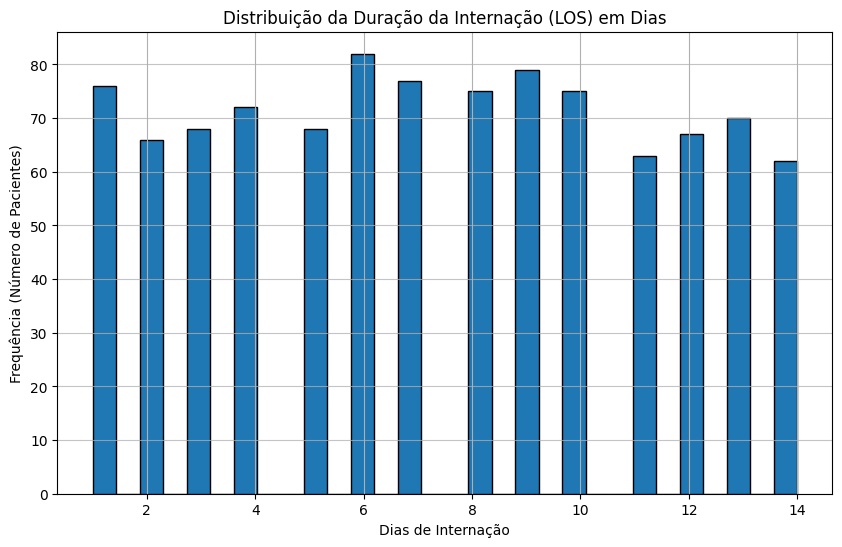

Gráfico 'los_distribution.png' gerado para visualização da distribuição do LOS.


In [3]:
# Converter colunas de data em df_pat
df_pat['arrival_date'] = pd.to_datetime(df_pat['arrival_date'])
df_pat['departure_date'] = pd.to_datetime(df_pat['departure_date'])

# Calcular a Duração da Internação (Length of Stay - LOS) em dias
# O resultado da subtração é um objeto timedelta, .dt.days extrai os dias.
df_pat['LOS_days'] = (df_pat['departure_date'] - df_pat['arrival_date']).dt.days

print("Estatísticas Descritivas da Duração da Internação (LOS) em dias")
print(df_pat['LOS_days'].describe().to_string())

# Plotar o histograma da LOS
plt.figure(figsize=(10, 6))
df_pat['LOS_days'].hist(bins=30, edgecolor='black')
plt.title('Distribuição da Duração da Internação (LOS) em Dias')
plt.xlabel('Dias de Internação')
plt.ylabel('Frequência (Número de Pacientes)')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Gráfico 'los_distribution.png' gerado para visualização da distribuição do LOS.")

In [4]:
# Calcular estatísticas descritivas da LOS, agrupadas por Serviço
los_by_service = df_pat.groupby('service')['LOS_days'].describe()

print("Estatísticas Descritivas da LOS (dias) por Serviço")
print(los_by_service.to_string())

Estatísticas Descritivas da LOS (dias) por Serviço
                  count      mean       std  min   25%  50%   75%   max
service                                                                
ICU               241.0  7.605809  4.049461  1.0  4.00  8.0  11.0  14.0
emergency         263.0  7.159696  3.815043  1.0  4.00  7.0  10.0  14.0
general_medicine  242.0  6.995868  4.037683  1.0  3.25  7.0  10.0  14.0
surgery           254.0  7.866142  3.885439  1.0  4.00  8.0  11.0  14.0


In [5]:
# Analisar df_serv (Dados semanais de nível de serviço)
print("Estatísticas Descritivas Chave em df_serv")
service_metrics = df_serv.groupby('service')[['available_beds', 'patients_request', 'patients_admitted', 'patients_refused']].mean()
print(service_metrics.sort_values(by='patients_refused', ascending=False).to_string())

Estatísticas Descritivas Chave em df_serv
                  available_beds  patients_request  patients_admitted  patients_refused
service                                                                                
emergency              22.788462        119.096154          22.788462         96.307692
general_medicine       46.230769         82.115385          44.846154         37.269231
surgery                37.519231         43.096154          32.423077         10.673077
ICU                    14.846154         15.173077          12.461538          2.711538


In [6]:
#Analisar df_serv (Dados semanais de nível de serviço)
print("Moral da Equipe Média (Staff Morale) por Serviço")
morale_by_service = df_serv.groupby('service')['staff_morale'].mean()
print(morale_by_service.sort_values(ascending=True).to_string())

Moral da Equipe Média (Staff Morale) por Serviço
service
ICU                 70.980769
surgery             72.634615
general_medicine    73.096154
emergency           73.557692


In [7]:
# Contar o número de funcionários por cargo e serviço
staff_distribution = df_staff.groupby('service')['role'].value_counts().unstack(fill_value=0)

print("Distribuição de Funcionários por Serviço e Cargo")
print(staff_distribution.to_string())

Distribuição de Funcionários por Serviço e Cargo
role              doctor  nurse  nursing_assistant
service                                           
ICU                    6     18                  8
emergency              5     19                  5
general_medicine       3     19                  5
surgery                4     13                  5


In [8]:
# Investigar o impacto de 'event' nos pacientes recusados e na moral da equipe
event_analysis = df_serv.groupby('event')[['patients_refused', 'staff_morale']].mean()

print("Impacto de Eventos (como 'flu') na Recusa e Moral da Equipe")
print(event_analysis.to_string())

Impacto de Eventos (como 'flu') na Recusa e Moral da Equipe
          patients_refused  staff_morale
event                                   
donation         29.142857     80.142857
flu             126.157895     72.894737
none             28.378049     73.146341
strike           16.636364     53.727273


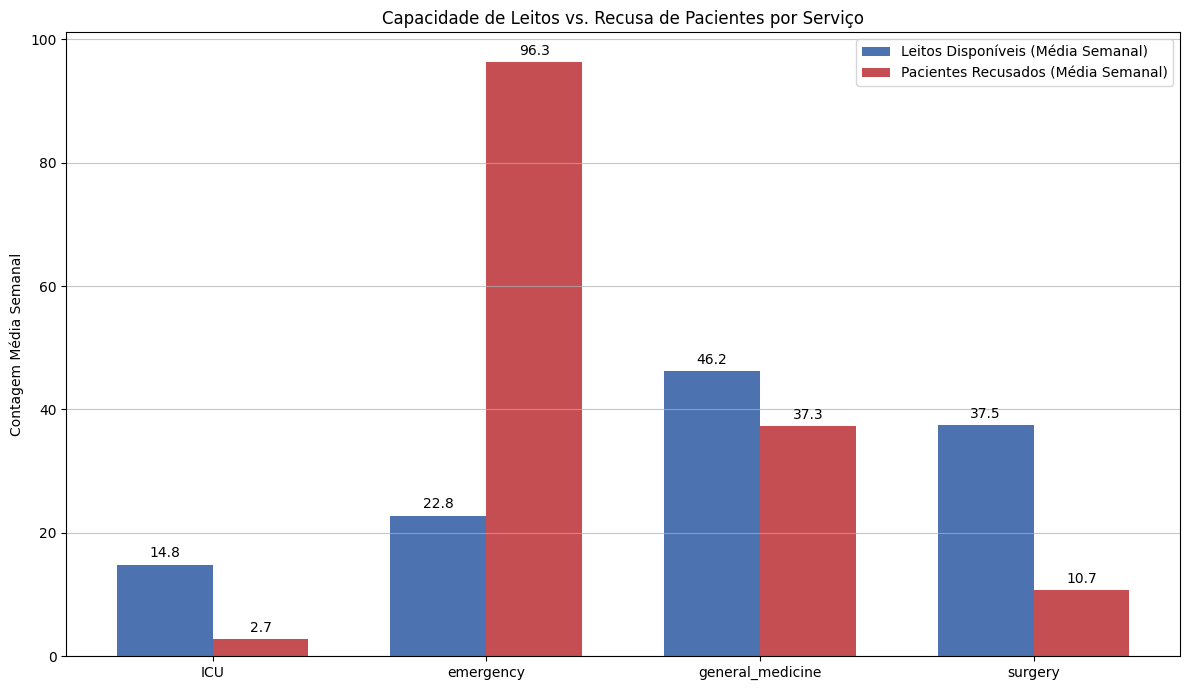

In [9]:
# Re-calcular as médias do df_serv
service_metrics = df_serv.groupby('service')[['available_beds', 'patients_refused']].mean()

# Criar a visualização
labels = service_metrics.index
available = service_metrics['available_beds']
refused = service_metrics['patients_refused']

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, available, width, label='Leitos Disponíveis (Média Semanal)', color='#4c72b0')
rects2 = ax.bar(x + width/2, refused, width, label='Pacientes Recusados (Média Semanal)', color='#c44e52')

ax.set_ylabel('Contagem Média Semanal')
ax.set_title('Capacidade de Leitos vs. Recusa de Pacientes por Serviço')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', alpha=0.7)

# Adicionar rótulos de dados
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [11]:
# Criar variáveis dummy para a coluna categórica 'event'
df_ml = pd.get_dummies(df_serv, columns=['event'], drop_first=True)

# 2. Definir Features (X) e Target (y)
features = ['available_beds', 'patients_request', 'staff_morale'] + [col for col in df_ml.columns if col.startswith('event_')]
X = df_ml[features]
y = df_ml['patients_refused']

# 3. Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Treinar o Modelo de Regressão Linear Simples
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Avaliar o Modelo
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print("Resultado do Modelo de Regressão para Previsão de Pacientes Recusados")
print(f"Erro Médio Absoluto (MAE): {mae:.2f} pacientes")
print("Este MAE representa o erro médio na previsão do número de pacientes recusados por semana.")

Resultado do Modelo de Regressão para Previsão de Pacientes Recusados
Erro Médio Absoluto (MAE): 3.07 pacientes
Este MAE representa o erro médio na previsão do número de pacientes recusados por semana.


In [12]:
from sklearn.tree import DecisionTreeRegressor

df_ml_los = df_pat.copy()
df_ml_los = pd.get_dummies(df_ml_los, columns=['service'], drop_first=True)

# 2. Definir Features (X) e Target (y)
# Usaremos 'age', 'satisfaction' e as dummies do 'service' como features.
features_los = ['age', 'satisfaction'] + [col for col in df_ml_los.columns if col.startswith('service_')]
X_los = df_ml_los[features_los]
y_los = df_ml_los['LOS_days']

# 3. Dividir os dados em treino e teste
X_train_los, X_test_los, y_train_los, y_test_los = train_test_split(X_los, y_los, test_size=0.2, random_state=42)

# 4. Treinar o Modelo de Regressão (Árvore de Decisão)
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_los, y_train_los)

# 5. Avaliar o Modelo
y_pred_los = dt_model.predict(X_test_los)
mae_los = mean_absolute_error(y_test_los, y_pred_los)

print("Resultado do Modelo de Árvore de Decisão para Previsão da Duração da Internação (LOS)")
print(f"Erro Médio Absoluto (MAE LOS): {mae_los:.2f} dias")
print("Este MAE representa o erro médio na previsão do tempo de internação de um paciente.")

Resultado do Modelo de Árvore de Decisão para Previsão da Duração da Internação (LOS)
Erro Médio Absoluto (MAE LOS): 4.61 dias
Este MAE representa o erro médio na previsão do tempo de internação de um paciente.


In [13]:
# Obter os coeficientes do modelo de Regressão Linear
# O coeficiente representa o impacto de uma unidade de mudança na feature sobre o target (patients_refused)
coefficients = pd.Series(model.coef_, index=features).sort_values(ascending=False)

print("Importância das Features (Coeficientes do Modelo de Recusa)")
print(coefficients.to_string())

Importância das Features (Coeficientes do Modelo de Recusa)
event_strike        4.813999
patients_request    0.964576
staff_morale       -0.029331
event_flu          -0.356069
available_beds     -0.870364
event_none         -1.033308


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df_pat['arrival_date'] = pd.to_datetime(df_pat['arrival_date'])
df_pat['departure_date'] = pd.to_datetime(df_pat['departure_date'])
df_pat['LOS_days'] = (df_pat['departure_date'] - df_pat['arrival_date']).dt.days
# Extrair o número da semana para junção
df_pat['week'] = df_pat['arrival_date'].dt.isocalendar().week.astype(int)

# Criar a nova variável-alvo categórica (Classes de LOS)
# Definir classes: Curta (<= 4 dias), Média (5-10 dias), Longa (> 10 dias)
def classify_los(days):
    if days <= 4:
        return 'Curta'
    elif days <= 10:
        return 'Média'
    else:
        return 'Longa'

df_pat['LOS_class'] = df_pat['LOS_days'].apply(classify_los)

# Pré-processamento do df_serv (Agregação Contextual)
# Selecionar o contexto semanal relevante (leitos e moral)
df_serv_context = df_serv.groupby(['week', 'service'])[['available_beds', 'staff_morale']].mean().reset_index()

# Junção dos DataFrames (Melhoria da Feature)
# Juntar o contexto semanal do serviço ao registro do paciente
df_ml_los_new = pd.merge(
    df_pat, 
    df_serv_context, 
    on=['week', 'service'], 
    how='left'
)

# Codificação One-Hot para ML (Serviço e as Classes de LOS)
df_ml_los_final = pd.get_dummies(df_ml_los_new, columns=['service'], drop_first=True)

# Definição Final de Features e Target para Classificação
features_new = [
    'age', 
    'satisfaction', 
    'available_beds', # Nova feature contextual
    'staff_morale'    # Nova feature contextual
] + [col for col in df_ml_los_final.columns if col.startswith('service_')]

X_new = df_ml_los_final[features_new]
y_new = df_ml_los_final['LOS_class']
y_new = y_new.map({'Curta': 0, 'Média': 1, 'Longa': 2}) # Mapeamento para números

# Divisão dos dados
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42, stratify=y_new)

# Treinar o Modelo de Classificação (Random Forest, mais poderoso)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_new, y_train_new)

# Avaliação do Modelo
y_pred_new = rf_model.predict(X_test_new)

print(" Relatório de Classificação para Previsão de Classes de LOS (Melhorado)")
print(classification_report(y_test_new, y_pred_new, target_names=['Curta', 'Média', 'Longa']))

 Relatório de Classificação para Previsão de Classes de LOS (Melhorado)
              precision    recall  f1-score   support

       Curta       0.30      0.25      0.27        57
       Média       0.52      0.60      0.56        91
       Longa       0.22      0.21      0.22        52

    accuracy                           0.40       200
   macro avg       0.35      0.35      0.35       200
weighted avg       0.38      0.40      0.39       200



Importância das Features no Modelo de Classificação da LOS
age                         0.276584
satisfaction                0.258537
staff_morale                0.210857
available_beds              0.202000
service_emergency           0.019385
service_surgery             0.016949
service_general_medicine    0.015688


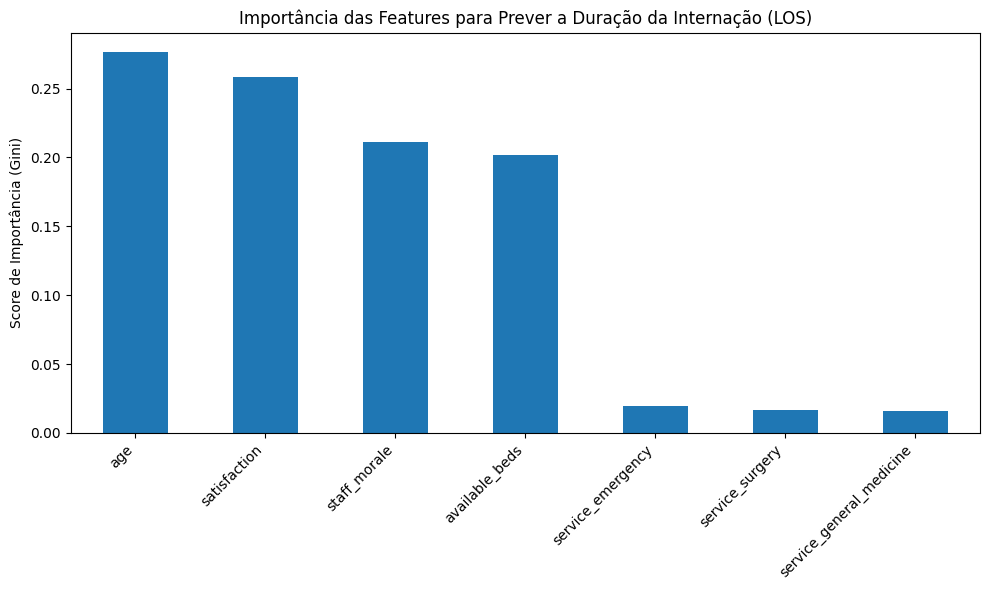

In [15]:
# Obter a importância das features do modelo Random Forest (rf_model)
feature_importances = pd.Series(rf_model.feature_importances_, index=X_new.columns).sort_values(ascending=False)

print("Importância das Features no Modelo de Classificação da LOS")
print(feature_importances.to_string())

# Visualização (opcional)
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar')
plt.title('Importância das Features para Prever a Duração da Internação (LOS)')
plt.ylabel('Score de Importância (Gini)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
import plotly.express as px
import dash
from dash import dcc, html
import dash_bootstrap_components as dbc

try:
    # Carregando os 4 arquivos CSV fornecidos
    df_pat = pd.read_csv('patients.csv') # Registros de pacientes
    df_serv = pd.read_csv('services_weekly.csv') # Dados semanais de nível de serviço
    df_staff = pd.read_csv('staff.csv') # Lista de funcionários
    df_schedule = pd.read_csv('staff_schedule.csv') # Horário da equipe
except FileNotFoundError:
    print("Erro: Não foi possível carregar um ou mais arquivos CSV. Verifique os nomes dos ficheiros.")
    exit()


In [17]:
# ----------------------------------------------------------------------
# 2. Preparação dos Dados (Limpeza, Cálculo de Métricas e Agregação)
# ----------------------------------------------------------------------

# Normalização de Nomes de Colunas (para minúsculas e sem espaços)
dfs = [df_pat, df_serv, df_staff, df_schedule]
for df in dfs:
    df.columns = df.columns.str.lower().str.strip()

# --- DF_SERV (Performance Semanal) ---
# 1. Taxa de Recusa (KPI Principal)
df_serv['rejection_rate'] = (df_serv['patients_refused'] / df_serv['patients_request']) * 100
df_serv['rejection_rate'] = df_serv['rejection_rate'].fillna(0)

# 2. Dados de Moral vs. Satisfação (Agregação para Scatter Plot)
df_morale_satisfaction = df_serv.groupby('service').agg(
    avg_morale=('staff_morale', 'mean'),
    avg_satisfaction=('patient_satisfaction', 'mean'),
    total_requests=('patients_request', 'sum')
).reset_index()

# --- DF_PAT (Duração da Internação - LOS) ---
# 1. Calcular LOS (Length of Stay)
df_pat['arrival_date'] = pd.to_datetime(df_pat['arrival_date'])
df_pat['departure_date'] = pd.to_datetime(df_pat['departure_date'])
df_pat['los_days'] = (df_pat['departure_date'] - df_pat['arrival_date']).dt.days

# 2. Classificação LOS
def classify_los(days):
    """Classifica a Duração da Internação (Length of Stay - LOS)."""
    if days <= 4:
        return 'Curta'
    elif days <= 10:
        return 'Média'
    else:
        return 'Longa'

df_pat['los_class'] = df_pat['los_days'].apply(classify_los)


# ----------------------------------------------------------------------
# 3. Criação dos Componentes Visuais (Plotly)
# ----------------------------------------------------------------------

def create_rejection_trend_chart(df):
    """Gráfico de linha da Taxa de Recusa ao longo das semanas por serviço."""
    fig = px.line(
        df,
        x='week', 
        y='rejection_rate',
        color='service',
        title='Tendência da Taxa de Recusa de Pacientes (%)',
        labels={'week': 'Semana', 'rejection_rate': 'Taxa de Recusa (%)'},
        template='plotly_white',
        markers=True
    )
    fig.update_layout(legend_title='Serviço', title_x=0.5)
    return fig

def create_los_distribution_chart(df):
    """Gráfico de barras da distribuição da Duração de Internação (LOS) por Serviço."""
    los_counts = df.groupby(['service', 'los_class']).size().reset_index(name='count')
    los_order = ['Curta', 'Média', 'Longa']
    
    fig = px.bar(
        los_counts,
        x='service',
        y='count',
        color='los_class',
        category_orders={'los_class': los_order},
        title='Distribuição da Duração da Internação (LOS)',
        labels={'service': 'Serviço', 'count': 'Número de Pacientes'},
        template='plotly_white'
    )
    fig.update_layout(barmode='stack', legend_title='Duração LOS', title_x=0.5)
    return fig

def create_morale_satisfaction_scatter(df):
    """Gráfico de dispersão da Moral da Equipe vs. Satisfação do Paciente por Serviço."""
    fig = px.scatter(
        df,
        x='avg_morale',
        y='avg_satisfaction',
        color='service',
        size='total_requests', # Tamanho do marcador pelo volume de pedidos
        text='service',
        title='Moral da Equipe vs. Satisfação do Paciente',
        labels={
            'avg_morale': 'Moral Média da Equipe (0-100)',
            'avg_satisfaction': 'Satisfação Média do Paciente (0-100)'
        },
        template='plotly_white'
    )
    fig.update_traces(textposition='top center')
    fig.update_layout(showlegend=False, title_x=0.5)
    fig.update_xaxes(range=[df['avg_morale'].min() - 5, df['avg_morale'].max() + 5])
    fig.update_yaxes(range=[df['avg_satisfaction'].min() - 5, df['avg_satisfaction'].max() + 5])
    return fig

# ----------------------------------------------------------------------
# 4. Layout do Dash (4 Componentes: 3 KPIs e 3 Gráficos)
# ----------------------------------------------------------------------

# 4.1 Cálculo de KPIs
avg_rejection = df_serv['rejection_rate'].mean()
avg_los = df_pat['los_days'].mean()
avg_morale = df_serv['staff_morale'].mean()

# 4.2 Inicialização do App
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.CERULEAN]) # Usando um tema diferente para contraste

# 4.3 Criação dos gráficos
rejection_chart = create_rejection_trend_chart(df_serv)
los_chart = create_los_distribution_chart(df_pat)
morale_satisfaction_chart = create_morale_satisfaction_scatter(df_morale_satisfaction)

app.layout = dbc.Container([
    # Título Principal
    dbc.Row(dbc.Col(html.H1("Dashboard de Performance Hospitalar", 
                           className="text-center text-primary my-4 fw-bold"), 
                   width=12)),
    
    # Linha 1: Cartões de KPIs
    dbc.Row([
        # KPI 1: Recusa Global
        dbc.Col(dbc.Card([
            dbc.CardHeader("Taxa Média de Recusa"),
            dbc.CardBody(
                html.H3(f"{avg_rejection:.2f}%", className="card-title text-danger")
            )
        ], color="light", outline=True, className="text-center shadow-sm h-100"), md=4, className="mb-4"),
        
        # KPI 2: LOS Global
        dbc.Col(dbc.Card([
            dbc.CardHeader("Duração Média Internação (LOS)"),
            dbc.CardBody(
                html.H3(f"{avg_los:.1f} dias", className="card-title text-info")
            )
        ], color="light", outline=True, className="text-center shadow-sm h-100"), md=4, className="mb-4"),
        
        # KPI 3: Moral da Equipe Global
        dbc.Col(dbc.Card([
            dbc.CardHeader("Moral Média da Equipe"),
            dbc.CardBody(
                html.H3(f"{avg_morale:.1f}", className="card-title text-success")
            )
        ], color="light", outline=True, className="text-center shadow-sm h-100"), md=4, className="mb-4"),
    ]),

    # Linha 2: Tendência de Recusa (Ocupa a largura total)
    dbc.Row([
        dbc.Col(dbc.Card([
            dbc.CardBody(dcc.Graph(figure=rejection_chart))
        ], className="shadow-sm h-100"), width=12, className="mb-4")
    ]),

    # Linha 3: LOS e Moral/Satisfação (Dividido)
    dbc.Row([
        dbc.Col(dbc.Card([
            dbc.CardBody(dcc.Graph(figure=los_chart))
        ], className="shadow-sm h-100"), lg=6, md=12, className="mb-4"),
        
        dbc.Col(dbc.Card([
            dbc.CardBody(dcc.Graph(figure=morale_satisfaction_chart))
        ], className="shadow-sm h-100"), lg=6, md=12, className="mb-4"),
    ]),
    
], fluid=True, className="bg-light p-4")


# ----------------------------------------------------------------------
# 5. EXECUÇÃO
# ----------------------------------------------------------------------

if __name__ == '__main__':
    print("\nIniciando o Dashboard BI Hospitalar...")
    print("Acesse no seu navegador: http://127.0.0.1:8050/")
    app.run(debug=True)


Iniciando o Dashboard BI Hospitalar...
Acesse no seu navegador: http://127.0.0.1:8050/


# Conclusão

O hospital tem um problema crônico de capacidade na Emergência, impulsionado pela demanda, e a melhor forma de aliviar isso é liberar leitos mais rapidamente nas alas de longa permanência (Cirurgia e UTI).

# Recomendação Estratégicas

**Reforço de Pessoal Focado:** Aumentar o número de Médicos (5) e Auxiliares de Enfermagem (5) no serviço de Emergência. O aumento do pessoal nesses cargos críticos pode acelerar a triagem e a liberação de leitos, aliviando a crise de recusa.

**Otimização do Fluxo de Leitos:** Implementar a Gestão Lean de Altas, com o objetivo de reduzir a LOS em Cirurgia e UTI, garantindo que as altas ocorram no início do dia.

**Monitoramento da Moral:** Investir em suporte e reconhecimento para a equipe da UTI (moral mais baixa de 70,98). Embora a moral não preveja a recusa, ela é crucial para evitar o esgotamento (burnout) e a rotatividade de pessoal.

**Aproveitamento do ML:** Utilizar o modelo de regressão para previsão de recusa para simular o impacto financeiro e operacional de novas contratações ou de um aumento na capacidade de leitos, justificando investimentos com base em dados.

# **Nathália Sorg**